# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
from matplotlib.colors import Normalize

from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import SymmetricalLogLocator
from scipy.interpolate import LinearNDInterpolator, griddata
import cmasher as cmr

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

# Individual Panels

## a: Zoom in gate map around CSC in nD

/tmp/ipykernel_752381/309910141.py:52: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


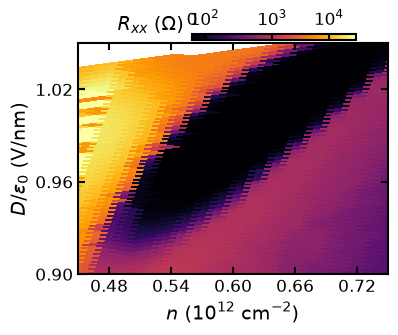

In [4]:
def plot_csc_gatemap(ax, norm, cmap="viridis", interpolate=False):
    file= 1354
    nx, ny = 201, 201
    
    ns = np.array([0.18, 0.8, 0.8, 0.18])
    Ds = np.array([1.016, 1.058, 0.60, 0.60])

    #file = 1912
    #ns = np.array([0.45, 0.72, 0.8, 0.8, 0.28])
    #Ds = np.array([1.04, 1.065, 1.058, 0.80, 0.80])
    #nx, ny = 101, 101

    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    
    verts = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts.append([Vtg, Vbg])
    
    verts = np.array(verts)
    
    contact_pairs = {
        'long1': {'indices': [3,], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
 
    }
    
    gates = False
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            # load in the new data
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            xs = data['xs'][0] # top gate
            ys = data['xs'][1] # back gate
            phase = data[f'sr830_{ind}_P']
            phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
    
            if pair=='curr':
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                zs= I/(md['comments'][1]['I_ac']*1E-9)
            else:
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                
                mask = np.abs(I) < 0.9 * 1E-9
                zs = np.ma.array(zs, mask=mask)
    
            xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=False)
            xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 0, rev_x=False, rev_y=False)
    
            if not gates:
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
                ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            else:
                ax.set_ylabel(r'$V_{Si}$ (V)')
                ax.set_xlabel(r'$V_{bg}$ (V)')

            if interpolate:
                # flatten and drop masked / NaN points (griddata only wants valid samples)
                zs_filled = np.ma.filled(zs, np.nan).ravel()
                pts   = np.column_stack([xs.ravel(), ys.ravel()])
                good  = np.isfinite(pts).all(axis=1) & np.isfinite(zs_filled)
                
                pts_good = pts[good]
                zs_good  = zs_filled[good]
                
                # target uniform grid in (n, D)
                n_grid = np.linspace(0.4, 0.8, 400)
                D_grid = np.linspace(0.9, 1.05, 400)
                N, D = np.meshgrid(n_grid, D_grid)
                
                # cubic interpolation
                zs_cubic = griddata(pts_good, zs_good, (N, D), method='cubic')
                plot = ax.pcolormesh(N, D, zs_cubic, norm=norm, cmap=cmap, rasterized=True, lw=0, shading="auto")
                
            else:
                plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0, shading="auto")
            ax.set_xlim(0.45, 0.75)
            ax.set_ylim(0.9, 1.05)
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))

            #ax.scatter(0.59, 1, s=50, marker="D", color="gold")
            #ax.scatter(0.6, 1.01, s=50, marker="o", color="green")

            return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=500, vmin=0, vmax=3E4)
plot = plot_csc_gatemap(ax, norm, "inferno", interpolate=False)

cax = fig.add_axes([0.41, 0.89, 0.41, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-15, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  

['/home/aaron/Fermiology-and-the-cCSC/figs/fig2_csc_gatemap_1479.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig2_csc_gatemap_1479.png']

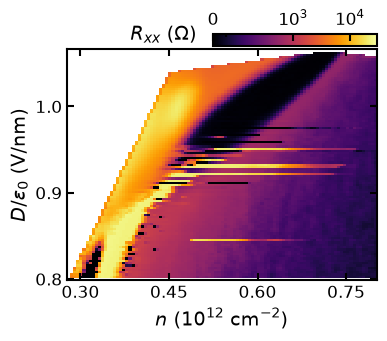

In [5]:
def plot_csc_gatemap_1479(ax, norm, cmap="viridis", interpolate=False):
    file= 1479
    ns = np.array([0.45, 0.72, 0.8, 0.8, 0.28])
    Ds = np.array([1.04, 1.065, 1.058, 0.80, 0.80])

    nx, ny = 101, 101
   
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    
    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)

    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long1': {'indices': [1,], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
 
    }
    
    gates = False
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            # load in the new data
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            xs = data['xs'][0] # top gate
            ys = data['xs'][1] # back gate
            phase = data[f'sr830_{ind}_P']
            phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
    
            if pair=='curr':
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                zs= I/(md['comments'][1]['I_ac']*1E-9)
            else:
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                
                mask = np.abs(I) < 0.9 * 1E-9
                zs = np.ma.array(zs, mask=mask)
            xs, ys = calculate_n_D(xs, ys, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
            xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=True)
            xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 0, rev_x=False, rev_y=True)

            plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0, shading="auto")
            #ax.set_xlim(0.45, 0.75)
            #ax.set_ylim(0.9, 1.05)
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')

            #ax.scatter(0.59, 1, s=50, marker="D", color="gold")
            #ax.scatter(0.6, 1.01, s=50, marker="o", color="green")

            return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=500, vmin=0, vmax=3E4)
# norm = colors.Normalize(vmin=0, vmax=1000)
plot = plot_csc_gatemap_1479(ax, norm, "inferno", interpolate=False)

cax = fig.add_axes([0.49, 0.89, 0.41, 0.04])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1000, 10000], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-22, x=-0.3)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, 'fig2_csc_gatemap_1479')

## b: n cuts

<>:75: SyntaxWarning: invalid escape sequence '\O'
<>:75: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_752381/5309714.py:75: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel('$R_{xx}$ ($\Omega$)')
/tmp/ipykernel_752381/5309714.py:48: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


['/home/aaron/Fermiology-and-the-cCSC/figs/fig2_csc_gatemap_1354_ncuts.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig2_csc_gatemap_1354_ncuts.png']

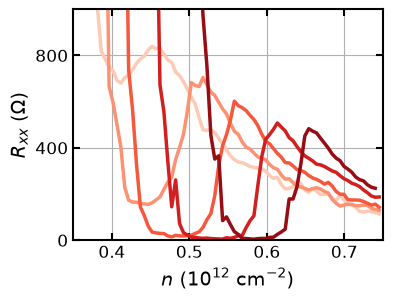

In [6]:
def plot_ncuts(ax):
    file= 1354
    nx, ny = 201, 201

    ns = np.array([0.18, 0.8, 0.8, 0.18])
    Ds = np.array([1.016, 1.058, 0.60, 0.60])
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts.append([Vtg, Vbg])
    
    verts = np.array(verts)
    
    contact_pairs = {
        'long1': {'indices': [1,], 'norm': colors.SymLogNorm(linthresh=50, vmin=-1E4, vmax=1E4), 'cmap': 'RdBu_r', 'label': r'$R_{xx}$ ($\Omega$)'},
        'hall1': {'indices': [], 'norm': colors.SymLogNorm(linthresh=50, vmin=1E3, vmax=1E5), 'cmap': 'viridis', 'label': r'$R_{yx}$ ($\Omega$)'},
    }
    
    gates = False
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:            
        
            # load in the new data
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            xs = data['xs'][0] # top gate
            ys = data['xs'][1] # back gate
            phase = data[f'sr830_{ind}_P']
            phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
    
            if pair=='curr':
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                zs= I/(md['comments'][1]['I_ac']*1E-9)
            else:
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                
                mask = np.abs(I) < 0.8 * 1E-9
                zs = np.ma.array(zs, mask=mask)
    
            xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=False)
            xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 0, rev_x=False, rev_y=False)

            if not gates:
                xs, ys = calculate_n_D(xs, ys, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
               
            inds = range(1, 90, 20)
            
            cs = plt.cm.Reds(np.linspace(0.2,0.9, len(inds)))
            interp = LinearNDInterpolator((xs.flatten(), ys.flatten()), zs.flatten())  
            xs_new = np.linspace(0.25, 0.75, 100)
            ys_new = np.linspace(0.9, 1.05, 100)
            xs_new, ys_new = np.meshgrid(xs_new, ys_new, indexing='ij')
                    
            # Interpolate
            zs_new = interp((xs_new, ys_new)) 
        
            for i, ind in enumerate(inds):
                ax.plot(xs_new[:,ind],zs_new[:,ind], color=cs[i])
            ax.set_xlim(0.35, 0.75)
            ax.set_ylim(0, 1000)
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylabel('$R_{xx}$ ($\Omega$)')
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))
            #ax.axvline(0.68)
            return inds, xs_new, ys_new


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
inds, xs, ys = plot_ncuts(ax)
# ax.set_ylim(-20,20)
# ax.set_xlim(0.45, 0.65)
ax.grid()
save_fig(fig, 'fig2_csc_gatemap_1354_ncuts')

## c: Temp dep., R vs T

/tmp/ipykernel_752381/1123634490.py:60: UserWarning: Adding colorbar to a different Figure <Figure size 400x300 with 2 Axes> than <Figure size 400x300 with 2 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(plot, cax=cax, ticks=[0, 1000, 10000], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)


['/home/aaron/Fermiology-and-the-cCSC/figs/fig2_sc_dome_1425.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig2_sc_dome_1425.png']

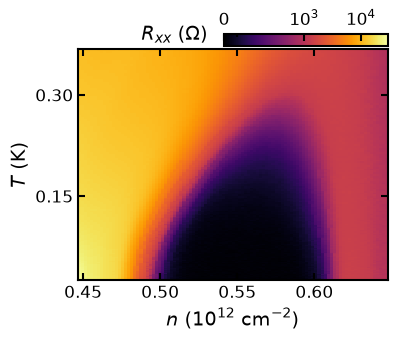

In [7]:
def plot_sc_dome(fig, ax, norm, cmap="viridis"):
    files= [1425]  
    contact_pairs = {
        'long1': {'indices': [1], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    } 
    gates = True
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for file in files:
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs_vbg = data['xs'][1]
                xs_vtg = data['xs'][0]
                ys = data['ys'][0]
                #ns, Ds = calculate_n_D(xs_vtg, xs_vbg, dtg=17.25, dbg=25.5)
                ns, Ds = calculate_n_D(xs_vtg, xs_vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
                xs = ns    
                temps = np.nanmean(data['T'], axis=1)
                ys = temps            
                phase = data[f'sr830_{ind}_P']
                if pair=='curr':
                    I = data['sr830_4_X']
                    I_expect = md['comments'][1]['I_ac']*1E-9 
                    zs= I/I_expect
                else:
                    I = data['sr830_4_X']
                    
                    Vxx = data[f'sr830_{ind}_X']
                    zs = Vxx / I
                    
                    mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                    zs = np.ma.array(zs, mask=mask)            
                plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)  
            #ax.xaxis.set_label_position('top')
            #ax.xaxis.tick_top()
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylabel('$T$ (K)')
            #ax.axvline(0.59, ls="--", color="white")
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    
    return plot
    
    
fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=500, vmin=0, vmax=5E3)
# norm = colors.Normalize(vmin=0, vmax=1000)
plot_sc_dome(fig, ax, norm, cmap="inferno")

cax = fig.add_axes([0.49, 0.89, 0.41, 0.04])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1000, 10000], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-22, x=-0.3)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  

save_fig(fig, 'fig2_sc_dome_1425')

<>:30: SyntaxWarning: invalid escape sequence '\O'
<>:30: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_752381/3604855883.py:30: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel("R (k$\Omega$)")


(0.0, 0.2)

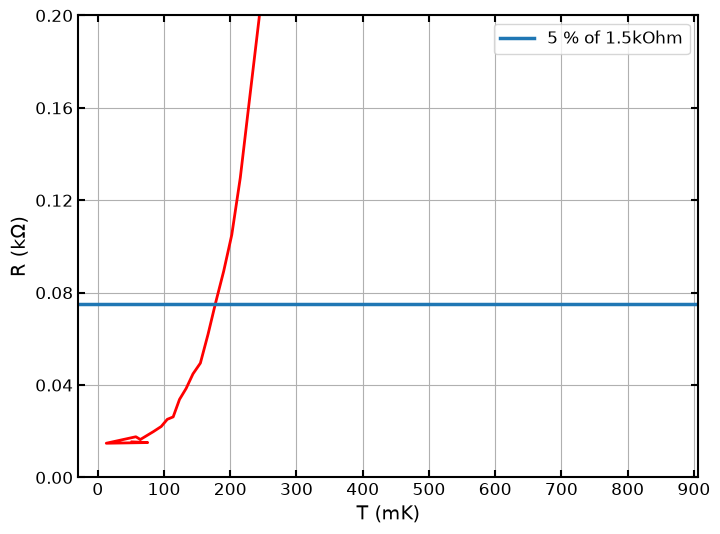

In [8]:
def plot_RT_onept(fig, ax, color="r"):  
    # 300ms time constant
    files= [2026]
    
    contact_pairs = {
        'long': {'indices': [1], 'norm': colors.SymLogNorm(linthresh=10, vmin=-3E4, vmax=3E4), 'cmap': 'RdBu_r', 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    for pair, options in contact_pairs.items():   
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for i, file in enumerate(files):
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                idc_vec = data['xs']
                phase = data[f'sr830_{ind}_P']
                temp_vec = data['T_probe']
    
                I = data['sr830_4_X']
                Vxx = data[f'sr830_{ind}_X']
                zs = Vxx/I
                
                ax.plot(temp_vec[::10]*1e3, zs[::10]/1e3, color=color, lw=2.0)    
            ax.set_ylabel("R (k$\Omega$)")
            ax.set_xlabel('T (mK)')
            ax.xaxis.set_major_locator(plt.MaxNLocator(10))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.axhline(0.05*1.5, label="5 % of 1.5kOhm")
            ax.grid()
            ax.legend()
    

fig = plt.figure(figsize=(8,6))
ax = plt.gca()
plot_RT_onept(fig, ax)
#ax.set_xlim(150,200)
ax.set_ylim(0,0.2)

<>:30: SyntaxWarning: invalid escape sequence '\O'
<>:30: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_752381/1304908922.py:30: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel("R (k$\Omega$)")


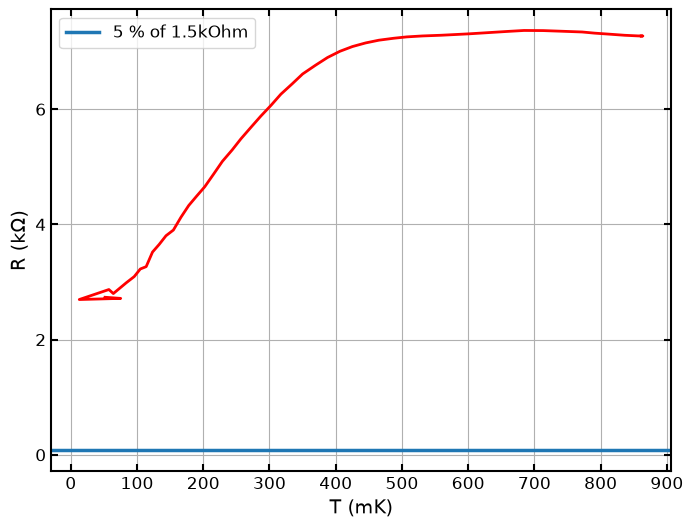

In [9]:
def plot_RT_onept(fig, ax, color="r"):  
    # 300ms time constant
    files= [2026]
    
    contact_pairs = {
        'long': {'indices': [1], 'norm': colors.SymLogNorm(linthresh=10, vmin=-3E4, vmax=3E4), 'cmap': 'RdBu_r', 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    for pair, options in contact_pairs.items():   
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for i, file in enumerate(files):
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                idc_vec = data['xs']
                phase = data[f'sr830_{ind}_P']
                temp_vec = data['T_probe']
    
                I = data['sr830_4_X']
                Vxx = data[f'sr830_{ind}_X']
                zs = Vxx/I
                
                ax.plot(temp_vec[::10]*1e3, np.log(zs[::10]), color=color, lw=2.0)    
            ax.set_ylabel("R (k$\Omega$)")
            ax.set_xlabel('T (mK)')
            ax.xaxis.set_major_locator(plt.MaxNLocator(10))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.axhline(0.05*1.5, label="5 % of 1.5kOhm")
            ax.grid()
            ax.legend()
    

fig = plt.figure(figsize=(8,6))
ax = plt.gca()
plot_RT_onept(fig, ax)

## d: Field dep vs density

/tmp/ipykernel_752381/1129364329.py:63: UserWarning: Adding colorbar to a different Figure <Figure size 400x300 with 2 Axes> than <Figure size 400x300 with 2 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(plot, cax=cax, ticks=[0, 1000, 10000], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)


['/home/aaron/Fermiology-and-the-cCSC/figs/fig2_field_dome_1681_1683.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig2_field_dome_1681_1683.png']

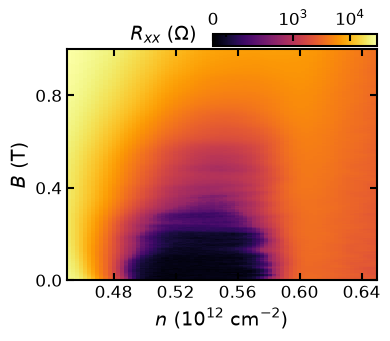

In [10]:
def plot_field_dome(fig, ax, norm, cmap="viridis"):
    # Incorrectly labeled MC_25
    files= [1681, 1682, 1683]
    
    cmapplt = plt.get_cmap('inferno')
    
    contact_pairs = {
        'curr': {'indices': [], 'norm': colors.Normalize(vmin=0, vmax=1), 'cmap': 'viridis', 'label': r'$I/I_0$'},
        'long1': {'indices': [1], 'norm': norm, \
                  'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    gates = True
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for file in files:
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                vtg = data['xs'][0]
                vbg = data['xs'][1]
                xs, _ = calculate_n_D(vtg, vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
                ys = data['ys'][0]
                phase = data[f'sr830_{ind}_P']

                if pair=='curr':
                    I = data['sr830_4_X']
                    zs= I
                else:
                    I = data['sr830_4_X']
                    Vxx = data[f'sr830_{ind}_X']
                    zs = Vxx/I
                    
                    mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                    zs = np.ma.array(zs, mask=mask)
        
                plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
            ax.set_ylabel(r'$B$ (T)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
    
            ax.set_ylim(0, 1)
            ax.set_xlim(0.45, 0.65)
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))

            return plot
    

fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=4E3)
#norm = colors.Normalize(vmin=0, vmax=3e3)
plot_field_dome(fig, ax, norm, cmap="inferno")

cax = fig.add_axes([0.49, 0.89, 0.41, 0.04])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1000, 10000], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-22, x=-0.3)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  

save_fig(fig, 'fig2_field_dome_1681_1683')

## e: Fraunhofer

<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_752381/2313493525.py:39: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$I_{\mathrm{dc}}$ (nA)")


['/home/aaron/Fermiology-and-the-cCSC/figs/fig2_fraunhofer_1400.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig2_fraunhofer_1400.png']

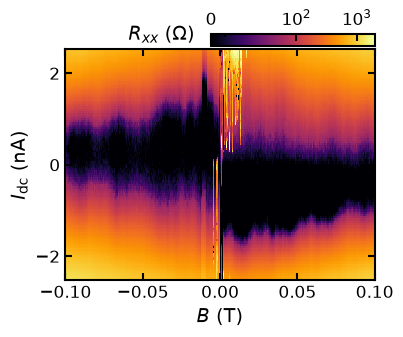

In [11]:
def plot_fraun(fig, ax, norm, cmap="viridis"):
    files= [1400]
    
    contact_pairs = {
        'long1': {'indices': [2], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    gates = True
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for file in files:
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs = data['xs']
                ys = data['ys']
                phase = data[f'sr830_{ind}_P']
        
                if pair=='curr':
                    I = data['sr830_4_X']
                    zs= I/(md['comments'][1]['I_ac']*1E-9)
                else:
                    I = data['sr830_4_X']
                    Vxx = data[f'sr830_{ind}_X']
                    zs = Vxx / I
                    
                    mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                    zs = np.ma.array(zs, mask=mask)
 
                plot = ax.pcolormesh(ys, xs*10, zs.T, norm=norm, cmap=cmap, rasterized=True, lw=0) # factor of 10 converts to nA
            ax.set_xlabel("$B$ (T)")
            ax.set_ylabel("$I_{\mathrm{dc}}$ (nA)")
            ax.xaxis.set_major_locator(plt.MaxNLocator(5))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
#norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1E3)
norm = colors.SymLogNorm(linthresh=50, vmin=0e3, vmax=2e3)
plot = plot_fraun(fig, ax, norm, cmap='inferno')
#ax.set_xlim(-0.05,0.)

cax = fig.add_axes([0.49, 0.89, 0.41, 0.04])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1000, 10000], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-22, x=-0.3)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, 'fig2_fraunhofer_1400')

## f: Rxy below and above Tc

In [12]:
def plot_hysteresis(fig, ax, file1=1564, file2=1608):
    files1 = [file1, file1+1]
    files2 = [file2, file2+1]

    contact_pairs = {
        'curr': {'indices': [], 'norm': colors.Normalize(vmin=0, vmax=1), 'cmap': 'viridis', 'label': r'$I/I_0$'},
        'long1': {'indices': [], 'norm': colors.SymLogNorm(linthresh=10, vmin=-3E4, vmax=3E4), 'cmap': 'RdBu_r', 'label': r'$R_{xx}$ ($\Omega$)'},
        'fakehall': {'indices': [3], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-5E3, vmax=5E3), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
        'realhall': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
        'nl': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
     }
    
    gates = True
    
    zs_arr = []
    for files in [files1, files2]:
        for pair, options in contact_pairs.items():
            indices = options['indices']
            norm = options.get('norm', None)
            cmap = options['cmap']
            label = options['label']
            vmin = options.get('vmin', None)
            vmax = options.get('vmax', None)
            for ind in indices:
                for file in files:
                    data = sl.pload(file_path, file)
                    mc_0 = data['measurement_config']
                    md = sl.load_meta(file_path, file)
                    xs = data['xs']
            
                    if pair=='curr':
                        I = data['sr830_4_X']
                        zs= I
                        zs_arr.append(zs)
                    else:
                        I = data['sr830_4_X']
                        Vxx = data[f'sr830_{ind}_X']
                        zs = Vxx/I
                        
                        mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                        zs = np.ma.array(zs, mask=mask)
                        zs_arr.append(zs)
        
    # zs_arr now has 4 traces, 2 corresponding to fiels1 and 2 to files2
    ax.plot(xs, 0.5*(zs_arr[3] - zs_arr[2]), label="500 mK", lw=2, color="darkorange")
    ax.plot(xs, 0.5*(zs_arr[1] - zs_arr[0]), label="28 mK", lw=2, color="teal")
    ax.legend(frameon=False)
    ax.set_xlabel("$B$(T)")
    ax.set_ylabel("$R_{xy}^{\mathrm{as}}$ ($\Omega$)")

    return

<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_752381/3770071465.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$R_{xy}^{\mathrm{as}}$ ($\Omega$)")


['/home/aaron/Fermiology-and-the-cCSC/figs/fig2_hysteresis_1564_1608.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig2_hysteresis_1564_1608.png']

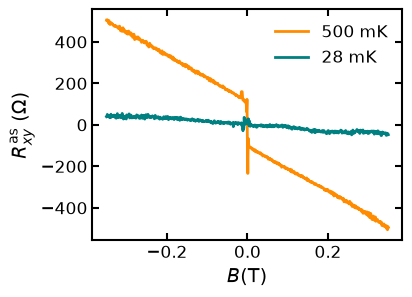

In [13]:
fig = plt.figure(figsize=(4,3))
ax = plt.gca()
plot_hysteresis(fig, ax)
# ax.set_ylim(-700,700)
# ax.set_ylim(-50, 50)
# ax.set_xlim(-0.25, 0.25)
save_fig(fig, 'fig2_hysteresis_1564_1608')

# Full figure

/tmp/ipykernel_752381/5309714.py:48: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


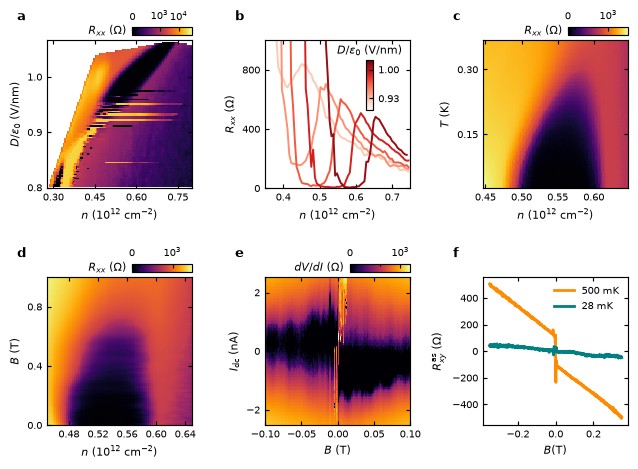

/tmp/ipykernel_752381/1270001763.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [14]:
update_rc_params('paper')  # paper style for this final figure

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 5))
gs = GridSpec(2, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[0.5, 0.5],
                       hspace=0.6, wspace=0.5)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=500, vmin=0, vmax=5E4)
plot = plot_csc_gatemap_1479(ax, norm, "inferno")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100),
                  orientation='horizontal')
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticks([0, 1000, 10000])
cb.set_ticklabels(['0', '$10^3$', '$10^4$'])

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

inds, xs, ys = plot_ncuts(ax)
Ds = ys[0, inds]
cax = fig.add_axes([0.55, 0.74, 0.01, 0.1])
cb = plt.colorbar(cm.ScalarMappable(norm=Normalize(vmin=Ds.min(), vmax=Ds.max()), cmap="Reds"),
                  cax=cax, orientation='vertical')
cb.ax.annotate(r'$D/\epsilon_0$ (V/nm)', xy=(0.5, 1.3), xycoords='axes fraction',
               ha='center', va='top', fontsize=plt.rcParams['axes.labelsize'])
cb.set_ticks([0.93, 1.00])
cb.set_ticklabels(['0.93', '1.00'])

################ Panel c ##################
ax = fig.add_subplot(gs[0, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

norm = colors.SymLogNorm(linthresh=500, vmin=0, vmax=0.5E4)
plot = plot_sc_dome(fig, ax, norm, cmap="inferno")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=500),
                  orientation='horizontal')
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')
cb.set_ticks([0, 1000])
cb.set_ticklabels(['$0$', '$10^3$'])

################ Panel d ##################
ax = fig.add_subplot(gs[1, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "d", fontweight='bold')

norm = colors.SymLogNorm(linthresh=500, vmin=0, vmax=5E3)
plot = plot_field_dome(fig, ax, norm, cmap="inferno")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=500),
                  orientation='horizontal')
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticks([0, 1000])
cb.set_ticklabels(['$0$', '$10^3$'])

################ Panel e ##################
ax = fig.add_subplot(gs[1, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "e", fontweight='bold')

norm = colors.SymLogNorm(linthresh=50, vmin=0e3, vmax=3e3)
plot = plot_fraun(fig, ax, norm, cmap="inferno")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=500),
                  orientation='horizontal')
cb.ax.annotate(r'$dV/dI$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticks([0, 1000])
cb.set_ticklabels(['$0$', '$10^3$'])

################ Panel f ##################
ax = fig.add_subplot(gs[1, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "f", fontweight='bold')

plot_hysteresis(fig, ax)

plt.show()
fig.tight_layout()
fig.savefig("fig2.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default